<a href="https://colab.research.google.com/github/TitienBernard/Automatic-classification-of-English-poetry-by-metre/blob/main/comparing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automatic classification of English poetry by meter


## 1. Library import

In [12]:
import pandas as pd
import copy
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import MinMaxScaler


In [13]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Data import and manipulation

In [14]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_csv("/content/drive/MyDrive/forbetterverse.csv", sep=";")

Mounted at /content/drive


In [15]:
# keeping rows for which there is relevant data
df = df.dropna(subset=["met", "meter_quality", "feet_number"])
df = df.reset_index(drop=True)
# cleaning the column names
df["feet_number"] = df["feet_number"].replace("pentamer", "pentameter")

In [16]:
# transforming raw stress annotations ("+" for stressed, "-" for unstressed syllable) to binary sequences
def parse_real(x):
    x = x.split("|")[0] # sometimes two intepretations are given separated by "|" : we keep the first one
    """
    '--+--+' → [0,0,1,0,0,1]
    """
    return [1 if c == '+' else 0 for c in str(x) if c in ['+','-']]

df["sequence"] = df["real"].apply(parse_real)
df[["real", "sequence"]].head()

,real,sequence
0,+--+--+++,"[1, 0, 0, 1, 0, 0, 1, 1, 1]"
1,+--+--+-,"[1, 0, 0, 1, 0, 0, 1, 0]"
2,+-+--+--+,"[1, 0, 1, 0, 0, 1, 0, 0, 1]"
3,+--+--+--+,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 1]"
4,-+--+-+--+,"[0, 1, 0, 0, 1, 0, 1, 0, 0, 1]"


In [17]:
# putting foot type and number of feet per line to create metre classes
df["label_full"] = df["meter_quality"].str.lower() + "_" + df["feet_number"].str.lower()
print(df["label_full"].value_counts())

label_full
iambic_pentameter       732
iambic_tetrameter       345
iambic_trimeter         150
anapestic_tetrameter     35
anapestic_trimeter       26
trochaic_tetrameter      26
iambic_hexameter         22
anapestic_pentameter     17
dactylic_tetrameter      13
anapestic_hexameter       4
iambic_monometer          4
trochaic_trimeter         3
anapestic_monometer       2
spondaic_tetrameter       1
Name: count, dtype: int64


In [18]:
counts = df["label_full"].value_counts()

# Dropping too unfrequent classes
valid_labels = counts[counts >= 10].index
df = df[df["label_full"].isin(valid_labels)].reset_index(drop=True)

# Converting sting classes into numeric values
label_to_id = {"iambic_pentameter" : 0, "iambic_tetrameter" : 1, "iambic_trimeter": 2,"anapestic_tetrameter": 3, "anapestic_trimeter" : 4, "trochaic_tetrameter" : 5,  "iambic_hexameter" : 6, "anapestic_pentameter" : 7, "dactylic_tetrameter" : 8 }

In [19]:
df

,line,met,real,feet,feet_number,meter_quality,line_n,title,author,meter_nuber,sequence,label_full
0,"What was he doing, the great god Pan,",--+--+--+--+,+--+--+++,"What was |he do|ing, the great |god Pan,",tetrameter,anapestic,1,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 0, 1, 0, 0, 1, 1, 1]",anapestic_tetrameter
1,Down in the reeds by the river?,--+--+--+,+--+--+-,Down in |the reeds |by the river?,trimeter,anapestic,2,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 0, 1, 0, 0, 1, 0]",anapestic_trimeter
2,"Spreading ruin and scattering ban,",--+--+--+--+,+-+--+--+,"Spreading |ruin |and scat|tering ban,",tetrameter,anapestic,3,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter
3,"Splashing and paddling with hoofs of a goat,",--+--+--+--+,+--+--+--+,"Splashing |and pad|dling with hoofs |of a goat,",tetrameter,anapestic,4,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter
4,And breaking the golden lilies afloat,--+--+--+--+,-+--+-+--+,And break|ing the gold|en lil|ies afloat,tetrameter,anapestic,5,A Musical Instrument(1860),Elizabeth Barrett Browning,NaN,"[0, 1, 0, 0, 1, 0, 1, 0, 0, 1]",anapestic_tetrameter
...,...,...,...,...,...,...,...,...,...,...,...,...
1361,"And get knocked on the head for his labours,",--+--+--+,--+--+--+-,"And get knocked |on the head |for his labours,",trimeter,anapestic,4,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 0]",anapestic_trimeter
1362,"To do good to mankind is the chivalrous plan,",--+--+--+--+,--+--+--+--+,"To do good |to mankind |is the chiv|alrous plan,",tetrameter,anapestic,5,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter
1363,And is always as nobly requited;,--+--+--+,--+--+--+-,And is al|ways as no|bly requited;,trimeter,anapestic,6,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 0, 1, 0, 0, 1, 0, 0, 1, 0]",anapestic_trimeter
1364,"Then battle for freedom wherever you can,",--+--+--+--+,-+--+--+--+,"Then bat|tle for free|dom where|ver you can,",tetrameter,anapestic,7,When a Man Hath No Freedom(1820),"George Gordon, Lord Byron",NaN,"[0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1]",anapestic_tetrameter


/tmp/ipykernel_14368/590319913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, palette="viridis")


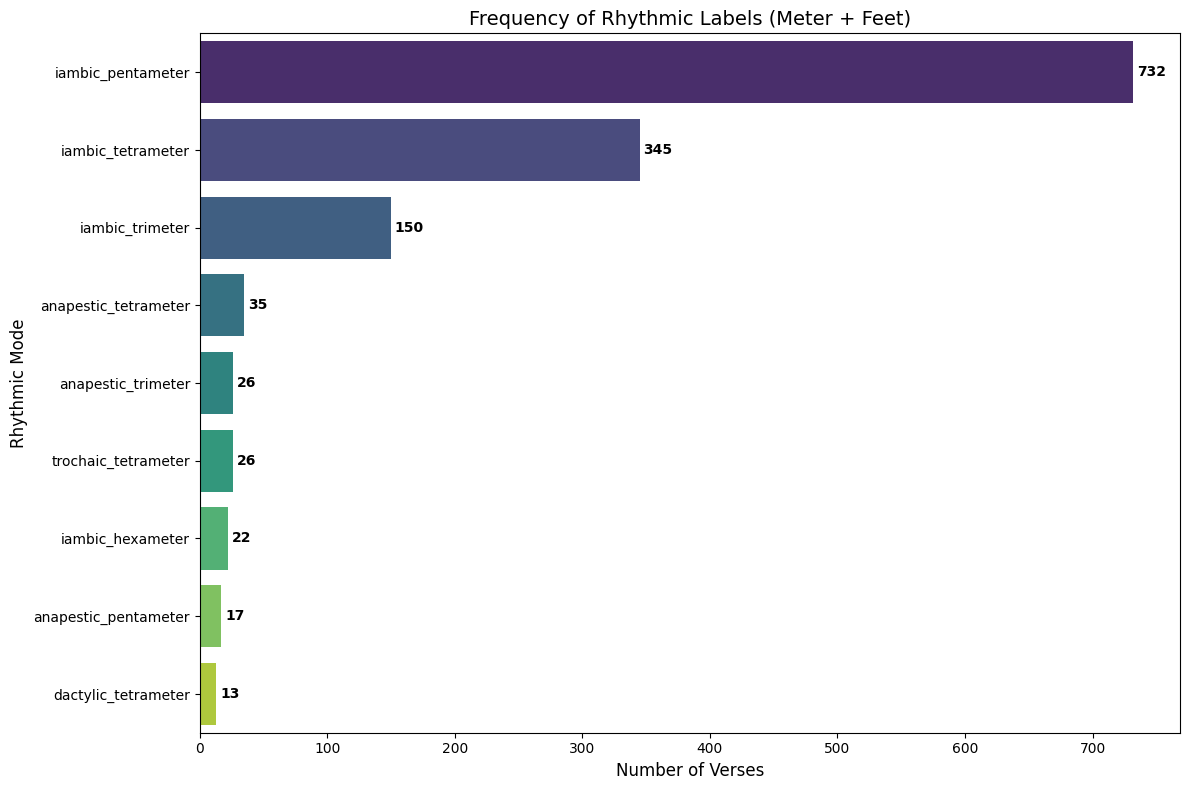

In [20]:
df["label_full"] = df["meter_quality"].str.lower() + "_" + df["feet_number"].str.lower()

# Calculate frequencies[cite: 1, 2]
counts = df["label_full"].value_counts()

# Set up the visualization
plt.figure(figsize=(12, 8))
sns.barplot(x=counts.values, y=counts.index, palette="viridis")

# Add chart details
plt.title("Frequency of Rhythmic Labels (Meter + Feet)", fontsize=14)
plt.xlabel("Number of Verses", fontsize=12)
plt.ylabel("Rhythmic Mode", fontsize=12)

# Annotate bars with the exact count
for i, v in enumerate(counts.values):
    plt.text(v + 3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Feature extraction

In [21]:
def extract_features(seq):
    """
    Convertit une séquence en vecteur de features
    """
    return [
        sum(seq)/len(seq),  # proportion de syllabes accentuées
        len(seq),  # longueur du vers
        sum(seq[i]==0 and seq[i+1]==1 for i in range(len(seq)-1)),  # transitions 0→1
        sum(seq[i]==1 and seq[i+1]==0 for i in range(len(seq)-1)),  # transitions 1→0
    ]

In [22]:
X_features = df["sequence"].reset_index(drop=True).apply(extract_features).tolist()
scaler = MinMaxScaler() # feature scaling
X_features = scaler.fit_transform(np.array(X_features))



```
# `Ce texte est au format code`
```

## 4. Data splitting

In [23]:
y = df["label_full"].apply(lambda x : label_to_id[x]).reset_index(drop=True)
X = df["sequence"].reset_index(drop=True)

In [24]:
data = []
for i in range(len(X)):
    data.append((X[i], X_features[i], y[i]))
len(data)

1366

In [25]:
# We use stratification because of the heterogeneity of our classes.
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, stratify=y)
y_temp = [label for _, _, label in temp_data]
dev_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42, stratify=y_temp)

In [26]:
# this dataset will presently be used to compare models
results_dev = pd.DataFrame({"datapoint_id": range(len(dev_data)),"gold_standard": [label for _, _, label in dev_data]})

## 5. Models

### 5.1 Feature-based MLP

> Ajouter une citation



In [27]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, n_layers=2, hidden_size=32):
        super().__init__()
        # Define the shape of the network as a list of layer sizes
        dims = [input_size] + [hidden_size] * (n_layers - 1) + [output_size]
        # Make the linear layers with ReLU in between each internal layer
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

In [28]:
def train_mlp(train_data, dev_data, n_epochs, lr=1e-3):
    model = MLP(input_size=4, output_size=9, hidden_size=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_loss = float("inf")
    best_state = None
    best_preds = None

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0

        for seq, features, label in train_data:

            x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)
            y = torch.tensor([label], dtype=torch.long)

            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_data)
        model.eval()
        y_true = []
        dev_preds = []
        dev_loss = 0

        with torch.no_grad():
            for seq, features, label in dev_data:
                x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)
                y = torch.tensor([label], dtype=torch.long)
                logits = model(x)
                loss = criterion(logits, y)
                dev_loss += loss.item()
                pred = torch.argmax(logits, dim=1).item()
                y_true.append(label)
                dev_preds.append(pred)

        dev_loss /= len(dev_data)
        dev_f1 = f1_score(y_true, dev_preds, average="macro", zero_division=0)

        if epoch % 10 == 0:
            print(epoch, train_loss, dev_loss, dev_f1)
        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            best_preds = dev_preds.copy()

    model.load_state_dict(best_state)

    return model, best_preds

In [29]:
mlp_model, mlp_preds = train_mlp(train_data, dev_data, 200)

0 1.3316509541919042 1.1145409914051614 0.0871697798730907
10 0.4607247354026307 0.4817789758305724 0.30385192762126656
20 0.3094490470255581 0.3396390712524696 0.518240101133234
30 0.24732450218161298 0.2802211220557915 0.6110420979986197
40 0.21578362464651374 0.25338561515176167 0.7060130745229943
50 0.19805354961976127 0.23894995179952963 0.7389136866325403
60 0.1883124434573965 0.23010628958794901 0.7244539584693037
70 0.18206817495000863 0.2256586367400681 0.7244539584693037
80 0.17787908382768927 0.2219413512540419 0.7244539584693037
90 0.17523803217963363 0.21980412770907407 0.714470061528885
100 0.17297312445311927 0.21907131958159437 0.7177470518784052
110 0.1709603841191706 0.2180198329938476 0.7177470518784052
120 0.16968215406794337 0.21662998126227714 0.7277309488188237
130 0.16792297432480097 0.2161963304597565 0.7277309488188237
140 0.16664021259441072 0.21741587623507325 0.7277309488188237
150 0.16602610953564503 0.2143188539172825 0.7401522920620848
160 0.164629479863

In [30]:
results_dev["MLP"] = mlp_preds

[texte du lien](https://)### 5.2 Rule-based model

In [31]:
def classify_rule_fixed(seq):
    classes = {
    'iambic_pentameter':     [0,1]*5,
    'iambic_tetrameter':     [0,1]*4,
    'iambic_trimeter':       [0,1]*3,

    'iambic_hexameter':      [0,1]*6,

    'trochaic_tetrameter':   [1,0]*4,

    'anapestic_trimeter':    [0,0,1]*3,
    'anapestic_tetrameter':  [0,0,1]*4,
    'anapestic_pentameter':  [0,0,1]*5,

    'dactylic_tetrameter':   [1,0,0]*4}

    best_score = -1
    best_label = None
    # Testing each type of metre
    for label, base_pattern in classes.items():

        # building a pattern whose length is equal to that of the sequence
        pattern = (base_pattern * (len(seq)//len(base_pattern)+2))[:len(seq)]

        #computing similarity
        score = sum(
            s == p for s, p in zip(seq, pattern)
        ) / len(seq)

        if score > best_score:
            best_score = score
            best_label = label

    return label_to_id[best_label]

In [32]:
rule_based_preds = []
for seq, _, _ in dev_data:
    pred = classify_rule_fixed(seq)
    rule_based_preds.append(pred)
results_dev["rule_based"] = rule_based_preds

In [33]:
results_dev

,datapoint_id,gold_standard,MLP,rule_based
0,0,0,0,8
1,1,0,0,0
2,2,1,1,5
3,3,1,1,0
4,4,1,1,0
...,...,...,...,...
200,200,0,0,0
201,201,0,0,0
202,202,0,0,0
203,203,0,0,5


In [34]:

f1_rule = f1_score(results_dev["gold_standard"], results_dev["rule_based"], average="macro")

print(f1_rule)

0.15022015022015023


*texte en italique*### 5.3 LSTMs

In [35]:
class MeterLSTM(nn.Module):

    def __init__(self, input_size=1, hidden_size=64, num_layers=1, num_classes=9):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.lin = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        # x shape:
        # (batch_size, seq_len, 1)

        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]

        logits = self.lin(last_hidden)

        return logits

In [36]:
def trainlstm(train_data, dev_data, n_epochs, learning_rate=1e-3):

    model = MeterLSTM(hidden_size=64)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    best_loss = float("inf")
    best_state = None
    best_dev_preds = None

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0

        for seq, _, label in train_data:

            x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            y = torch.tensor([label], dtype=torch.long)

            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_data)

        model.eval()
        y_true = []
        dev_preds = []
        dev_loss = 0
        with torch.no_grad():
            for seq, _, label in dev_data:
                x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
                y = torch.tensor([label], dtype=torch.long)
                logits = model(x)
                loss = criterion(logits, y)
                dev_loss += loss.item()
                pred = torch.argmax(logits, dim=1).item()
                y_true.append(label)
                dev_preds.append(pred)

        dev_loss /= len(dev_data)

        dev_f1 = f1_score(y_true, dev_preds, average="macro", zero_division=0)
        if epoch % 10 == 0:
            print("Epoch:", epoch)
            print("Train loss:", epoch_loss)
            print("Dev loss:", dev_loss)
            print("Dev F1:", dev_f1)

        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            best_dev_preds = dev_preds.copy()

    model.load_state_dict(best_state)

    return model, best_dev_preds

In [37]:
lstm_model, lstm_preds = trainlstm(train_data, dev_data, 100)

Epoch: 0
Train loss: 1.0316347755787887
Dev loss: 0.7656920273492976
Dev F1: 0.2821746690798112
Epoch: 10
Train loss: 0.3676955336797398
Dev loss: 0.3490219414325022
Dev F1: 0.5037588285074026
Epoch: 20
Train loss: 0.2648016963213503
Dev loss: 0.32471211326547056
Dev F1: 0.6259379458298454
Epoch: 30
Train loss: 0.16174425651194752
Dev loss: 0.29968875037930714
Dev F1: 0.6791593801929721
Epoch: 40
Train loss: 0.11333706038835371
Dev loss: 0.29511642624501977
Dev F1: 0.7085486190481095
Epoch: 50
Train loss: 0.09026832476150021
Dev loss: 0.2755693139741197
Dev F1: 0.7330075146560965
Epoch: 60
Train loss: 0.08517733902611861
Dev loss: 0.33581650301481514
Dev F1: 0.6680740872521694
Epoch: 70
Train loss: 0.06539979383535506
Dev loss: 0.3102978641147052
Dev F1: 0.7502935697952765
Epoch: 80
Train loss: 0.05854085807422429
Dev loss: 0.28177733544463723
Dev F1: 0.7535509560623715
Epoch: 90
Train loss: 0.05563400851770697
Dev loss: 0.30263091819127047
Dev F1: 0.7411935434114257


In [38]:
results_dev["LSTM"] = lstm_preds

In [39]:
results_dev

,datapoint_id,gold_standard,MLP,rule_based,LSTM
0,0,0,0,8,0
1,1,0,0,0,0
2,2,1,1,5,1
3,3,1,1,0,1
4,4,1,1,0,1
...,...,...,...,...,...
200,200,0,0,0,0
201,201,0,0,0,0
202,202,0,0,0,0
203,203,0,0,5,0


In [40]:
def evaluate(model, data):
  model.eval()
  y_true = []
  y_pred = []
  total_loss = 0
  criterion = nn.CrossEntropyLoss()
  with torch.no_grad():

      for seq, _, label in data:
          x = torch.tensor(seq, dtype=torch.float32)
          x = x.unsqueeze(0).unsqueeze(-1)
          y = torch.tensor([label], dtype=torch.long)

          logits = model(x)
          loss = criterion(logits, y)
          total_loss += loss.item()

          pred = torch.argmax(logits, dim=1).item()
          y_true.append(label)
          y_pred.append(pred)

  f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
  mean_loss = total_loss / len(data)

  return "F1 : ", f1, "mean loss : ", mean_loss

### 5.4 Linear classifier using features + LSTM's last hidden representations

In [41]:
#The idea is to combine the feature model with the LSTM by taking the results of the LSTM (the hidden last representations) and putting them into an MLP with the previous features.
class MeterLSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, num_global_features=4, num_classes=9):

        super().__init__()

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        self.lin = nn.Linear(hidden_size + num_global_features, num_classes)

    def forward(self, seq, global_features):

        # seq shape:
        # (batch, seq_len, 1)

        out, (h_n, c_n) = self.lstm(seq)
        last_hidden = h_n[-1]

        # concaténation
        combined = torch.cat([last_hidden, global_features], dim=1)

        logits = self.lin(combined)

        return logits

In [42]:
def trainLstmClassifier(train_data, dev_data, n_epochs, learning_rate=1e-3) :
  model = MeterLSTMClassifier()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  criterion = nn.CrossEntropyLoss()

  best_loss = float("inf")
  best_state = None
  best_dev_preds = None
  for epoch in range(n_epochs):
      epoch_loss = 0
      model.train()
      for seq, features, label in train_data:
          x_seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
          x_features= torch.tensor([features], dtype=torch.float32)
          y = torch.tensor([label], dtype=torch.long)

          logits = model(x_seq, x_features)
          loss = criterion(logits, y)
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()
      epoch_loss /= len(train_data)
      model.eval()
      y_true = []
      dev_preds = []
      dev_loss = 0
      with torch.no_grad():
              for seq, features, label in dev_data:
                  x_seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
                  x_features= torch.tensor([features], dtype=torch.float32)
                  y = torch.tensor([label])
                  logits = model(x_seq, x_features)
                  loss = criterion(logits, y)
                  dev_loss += loss.item()
                  pred = torch.argmax(logits, dim=1).item()
                  y_true.append(label)
                  dev_preds.append(pred)
      dev_f1 = f1_score(y_true, dev_preds, average="macro", zero_division=0)
      dev_loss = dev_loss / len(dev_data)
      if epoch % 10 == 0:
            print("Epoch:", epoch)
            print("Train loss:", epoch_loss)
            print("Dev loss:", dev_loss)
            print("Dev F1:", dev_f1)
      if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            best_dev_preds = dev_preds.copy()
  model.load_state_dict(best_state)
  return model, best_dev_preds

In [43]:
def evaluate2(model, data):
  model.eval()
  y_true = []
  y_pred = []
  total_loss = 0
  criterion = nn.CrossEntropyLoss()
  with torch.no_grad():
      for seq, features, label in data:
          x_seq = torch.tensor(seq, dtype=torch.float32)
          x_seq = x_seq.unsqueeze(0).unsqueeze(-1)
          x_features= torch.tensor([features], dtype=torch.float32)
          y = torch.tensor([label], dtype=torch.long)

          logits = model(x_seq, x_features)
          loss = criterion(logits, y)
          total_loss += loss.item()

          pred = torch.argmax(logits, dim=1).item()
          y_true.append(label)
          y_pred.append(pred)
  f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
  mean_loss = total_loss / len(data)
  return "F1 : ", f1, "mean loss : ", mean_loss

###

In [44]:
hybrid_model, hybrid_preds = trainLstmClassifier(
    train_data,
    dev_data,
    100
)

/tmp/ipykernel_14368/1112572171.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x_features= torch.tensor([features], dtype=torch.float32)


Epoch: 0
Train loss: 1.1464146746236785
Dev loss: 0.867819282049086
Dev F1: 0.17640513076794936
Epoch: 10
Train loss: 0.36891542793306126
Dev loss: 0.40192660613485226
Dev F1: 0.4551737216935455
Epoch: 20
Train loss: 0.2686188410228181
Dev loss: 0.29877398583765435
Dev F1: 0.6272704025064145
Epoch: 30
Train loss: 0.2365495405417076
Dev loss: 0.29621752854095906
Dev F1: 0.6895721842242278
Epoch: 40
Train loss: 0.17352955752024601
Dev loss: 0.24765446871666738
Dev F1: 0.7484127605574634
Epoch: 50
Train loss: 0.12811634950724599
Dev loss: 0.2748705424629606
Dev F1: 0.6742211085880337
Epoch: 60
Train loss: 0.10832725140132413
Dev loss: 0.34166355127292664
Dev F1: 0.6317968661637913
Epoch: 70
Train loss: 0.08604220967200303
Dev loss: 0.3734176308696766
Dev F1: 0.6710909092999944
Epoch: 80
Train loss: 0.08315251190993253
Dev loss: 0.3337389485882407
Dev F1: 0.6779959512517653
Epoch: 90
Train loss: 0.07955073915303287
Dev loss: 0.2102497687813167
Dev F1: 0.7756269661740699


In [45]:
results_dev["LSTM_classifier"] = hybrid_preds

## 6. Model comparison (permutation tests)

In [46]:
def permutation_test(model_1, model_2, n_perm=1000):
    y_true = results_dev["gold_standard"].values
    m1 = results_dev[model_1].values
    m2 = results_dev[model_2].values
    obs_diff = abs(f1_score(y_true, m1, average="macro") - f1_score(y_true, m2, average="macro"))

    count = 0
    for _ in range(n_perm):
        m1_perm = []
        m2_perm = []
        for i in range(len(results_dev)):
            if random.random() < 0.5:
                m1_perm.append(m1[i])
                m2_perm.append(m2[i])
            else:
                m1_perm.append(m2[i])
                m2_perm.append(m1[i])

        perm_diff = abs(f1_score(y_true, m1_perm, average="macro") - f1_score(y_true, m2_perm, average="macro"))

        if perm_diff >= obs_diff:
            count += 1

    p_value = (count + 1) / (n_perm + 1)
    return obs_diff, p_value

In [47]:
res1 = permutation_test("rule_based", "LSTM")
print(res1)

(0.6033308058422213, 0.000999000999000999)


In [48]:
labels_train  = [i for _ ,_ ,i in train_data]
majority_class = Counter(labels_train).most_common(1)[0][0]
majority_class

np.int64(0)

In [49]:
results_dev["majority_baseline"] = majority_class * len(results_dev)

In [50]:
for model in ['majority_baseline', 'rule_based','LSTM', 'LSTM_classifier', 'MLP']:
  print(f"F1 ({model}) : ", f1_score(results_dev["gold_standard"], results_dev[model], average="macro"))

F1 (majority_baseline) :  0.07760141093474426
F1 (rule_based) :  0.15022015022015023
F1 (LSTM) :  0.7535509560623715
F1 (LSTM_classifier) :  0.7706886945691316
F1 (MLP) :  0.7401522920620848


In [51]:
pairs = [("rule_based", "majority_baseline"), ("MLP", "majority_baseline"), ("LSTM_classifier", "MLP"), ("LSTM_classifier", "LSTM"), ("LSTM_classifier", "rule_based"), ("LSTM", "rule_based"),("LSTM", "MLP")]

In [52]:

for pair in pairs:
  _, p = permutation_test(pair[0], pair[1])
  print(f"{pair[0]} better than {pair[1]} : p_bonferroni = ", min(p * len(pairs), 1.0))

rule_based better than majority_baseline : p_bonferroni =  1.0
MLP better than majority_baseline : p_bonferroni =  0.006993006993006993
LSTM_classifier better than MLP : p_bonferroni =  1.0
LSTM_classifier better than LSTM : p_bonferroni =  1.0
LSTM_classifier better than rule_based : p_bonferroni =  0.006993006993006993
LSTM better than rule_based : p_bonferroni =  0.006993006993006993
LSTM better than MLP : p_bonferroni =  1.0


In [53]:
for model in [
    'majority_baseline',
    'rule_based',
    'MLP',
    'LSTM',
    'LSTM_classifier'
]:
    print(
        model,
        f1_score(
            results_dev["gold_standard"],
            results_dev[model],
            average="macro"
        )
    )

majority_baseline 0.07760141093474426
rule_based 0.15022015022015023
MLP 0.7401522920620848
LSTM 0.7535509560623715
LSTM_classifier 0.7706886945691316


##7. Final evaluation on test set

In [54]:
y_test = [label for _, _, label in test_data]

majority_preds_test = [majority_class] * len(test_data)

print("Majority baseline")
print("F1 =", f1_score(y_test, majority_preds_test, average="macro"))
print()

Majority baseline
F1 = 0.07760141093474426



In [55]:
rule_based_preds_test = []

for seq, _, _ in test_data:
    pred = classify_rule_fixed(seq)
    rule_based_preds_test.append(pred)

print("Rule-based model")
print("F1 =", f1_score(y_test, rule_based_preds_test, average="macro"))
print()

Rule-based model
F1 = 0.12602733248214876



In [56]:
mlp_model.eval()

mlp_preds_test = []

with torch.no_grad():

    for seq, features, label in test_data:

        x = torch.tensor(features, dtype=torch.float32).unsqueeze(0)

        logits = mlp_model(x)

        pred = torch.argmax(logits, dim=1).item()

        mlp_preds_test.append(pred)

print("MLP")
print("F1 =", f1_score(y_test, mlp_preds_test, average="macro"))
print()

MLP
F1 = 0.7456969098478532



In [57]:
lstm_model.eval()

lstm_preds_test = []

with torch.no_grad():

    for seq, _, label in test_data:

        x = torch.tensor(seq, dtype=torch.float32)
        x = x.unsqueeze(0).unsqueeze(-1)

        logits = lstm_model(x)

        pred = torch.argmax(logits, dim=1).item()

        lstm_preds_test.append(pred)

print("LSTM")
print("F1 =", f1_score(y_test, lstm_preds_test, average="macro"))
print()

LSTM
F1 = 0.7132141850588453



In [58]:
hybrid_model.eval()

hybrid_preds_test = []

with torch.no_grad():

    for seq, features, label in test_data:

        x_seq = torch.tensor(seq, dtype=torch.float32)
        x_seq = x_seq.unsqueeze(0).unsqueeze(-1)

        x_features = torch.tensor(
            [features],
            dtype=torch.float32
        )

        logits = hybrid_model(
            x_seq,
            x_features
        )

        pred = torch.argmax(
            logits,
            dim=1
        ).item()

        hybrid_preds_test.append(pred)

print("Hybrid")
print("F1 =", f1_score(
    y_test,
    hybrid_preds_test,
    average="macro"
))

Hybrid
F1 = 0.7594114662607814


In [59]:
results_test = pd.DataFrame({

    "Model": [
        "Majority baseline",
        "Rule-based",
        "MLP",
        "LSTM",
        "Hybrid"
    ],

    "Macro F1": [

        f1_score(
            y_test,
            majority_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            rule_based_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            mlp_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            lstm_preds_test,
            average="macro"
        ),

        f1_score(
            y_test,
            hybrid_preds_test,
            average="macro"
        )
    ]
})

results_test.sort_values(
    by="Macro F1",
    ascending=False
)

,Model,Macro F1
4,Hybrid,0.759411
2,MLP,0.745697
3,LSTM,0.713214
1,Rule-based,0.126027
0,Majority baseline,0.077601


In [60]:
results_test = pd.DataFrame({
    "gold_standard": y_test,
    "majority_baseline": majority_preds_test,
    "rule_based": rule_based_preds_test,
    "MLP": mlp_preds_test,
    "LSTM": lstm_preds_test,
    "LSTM_classifier": hybrid_preds_test
})

In [61]:
def permutation_test_test(model_1, model_2, n_perm=1000):

    y_true = results_test["gold_standard"].values

    m1 = results_test[model_1].values
    m2 = results_test[model_2].values

    observed_diff = abs(
        f1_score(y_true, m1, average="macro")
        -
        f1_score(y_true, m2, average="macro")
    )

    count = 0

    for _ in range(n_perm):

        m1_perm = []
        m2_perm = []

        for i in range(len(y_true)):

            if random.random() < 0.5:

                m1_perm.append(m1[i])
                m2_perm.append(m2[i])

            else:

                m1_perm.append(m2[i])
                m2_perm.append(m1[i])

        perm_diff = abs(
            f1_score(y_true, m1_perm, average="macro")
            -
            f1_score(y_true, m2_perm, average="macro")
        )

        if perm_diff >= observed_diff:
            count += 1

    p_value = (count + 1) / (n_perm + 1)

    return observed_diff, p_value

In [62]:
pairs = [

    ("LSTM_classifier", "LSTM"),

    ("LSTM_classifier", "MLP"),

    ("LSTM", "MLP"),

    ("LSTM_classifier", "rule_based"),

    ("LSTM", "rule_based"),

    ("MLP", "rule_based")
]

In [63]:
for pair in pairs:

    diff, p = permutation_test_test(
        pair[0],
        pair[1]
    )

    p_bonferroni = min(
        p * len(pairs),
        1.0
    )

    print(
        f"{pair[0]} vs {pair[1]}"
    )

    print(
        f"Difference in F1 = {diff:.4f}"
    )

    print(
        f"p-value (Bonferroni) = {p_bonferroni:.4f}"
    )

    print()

LSTM_classifier vs LSTM
Difference in F1 = 0.0462
p-value (Bonferroni) = 1.0000

LSTM_classifier vs MLP
Difference in F1 = 0.0137
p-value (Bonferroni) = 1.0000

LSTM vs MLP
Difference in F1 = 0.0325
p-value (Bonferroni) = 1.0000

LSTM_classifier vs rule_based
Difference in F1 = 0.6334
p-value (Bonferroni) = 0.0060

LSTM vs rule_based
Difference in F1 = 0.5872
p-value (Bonferroni) = 0.0060

MLP vs rule_based
Difference in F1 = 0.6197
p-value (Bonferroni) = 0.0060



In [64]:
id_to_label = {v:k for k,v in label_to_id.items()}

labels = [id_to_label[i] for i in range(len(id_to_label))]

In [65]:
print(
    classification_report(
        y_test,
        mlp_preds_test,
        target_names=labels,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

   iambic_pentameter       0.97      0.99      0.98       110
   iambic_tetrameter       0.89      0.96      0.92        51
     iambic_trimeter       1.00      1.00      1.00        23
anapestic_tetrameter       1.00      0.40      0.57         5
  anapestic_trimeter       1.00      1.00      1.00         4
 trochaic_tetrameter       0.50      0.25      0.33         4
    iambic_hexameter       1.00      1.00      1.00         3
anapestic_pentameter       0.50      0.33      0.40         3
 dactylic_tetrameter       0.50      0.50      0.50         2

            accuracy                           0.94       205
           macro avg       0.82      0.72      0.75       205
        weighted avg       0.94      0.94      0.93       205



In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    mlp_preds_test
)

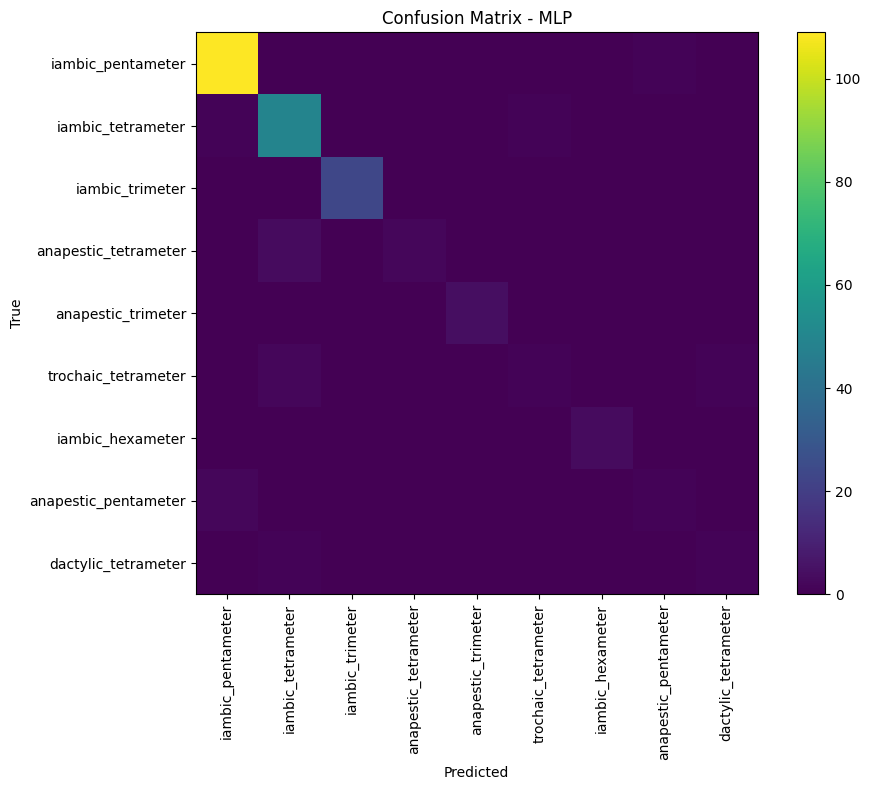

In [67]:
plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix - MLP")

plt.tight_layout()

plt.show()